# *Breast Cancer Detection Using Deep Learning (Fuzzy)*

# 01 - Data Exploration

Purpose:
- Load raw breast thermogram images
- Visualize sample images
- Inspect image size, channels and intensity range
- Verify dataset structure

Dataset(s):
- DMR-IR

In [1]:
import cv2
import sys, os
import numpy as np

In [2]:
sys.path.append(os.path.abspath(".."))

In [3]:
from src.sch_cs import run_schcs, SchCsStorageConfig
from src.features_extraction import run_feature_extraction
from src.chm_bias_correction import CHMConfig, CHMCorrector
from src.preprocessing import StorageConfig, run_preprocessing
from src.level_set_iteration import run_level_set, LevelSetConfig
from src.sr_segmentation import visualize_split, split_sr_left_right
from src.level_set_initialization import PhiInitConfig, LevelSetInitializer
from src.asymmetry_vector import visualize_asymmetry, compute_asymmetry_vector
from src.utils import PRE_CFG, SCH_CFG, load_schcs_results, load_preprocessing_results
from src.fann_classifier import build_fann, compute_metrics, visualize_results, run_cross_validation
from src.utils import (
    base_path,
    dmr_ir_o,
    schcs_results_path,
    sr_splits_results_path,
    preprocessed_results_path,
    chm_corrected_results_path,
    phi_initialized_result_path,
    asymmetric_vector_results_path,
    level_set_iterated_results_path
)

## STAGE 1: PRE-PROCESSING

In [4]:
DMR_IR_PATH = base_path + dmr_ir_o

image_files = sorted([
    f for f in os.listdir(DMR_IR_PATH)
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
])
print(f'Found {len(image_files)} images:')
for i, f in enumerate(image_files):
    print(f'  [{i}] {f}')

Found 17 images:
  [0] TFRON_V11_31-10-2012_0.jpg
  [1] TFRON_V12_31-10-2012_0.jpg
  [2] TFRON_V13_31-10-2012_0.jpg
  [3] TFRON_V15_31-10-2012_0.jpg
  [4] TFRON_V16_31-10-2012_0.jpg
  [5] TFRON_V1_26-10-2012_0.jpg
  [6] TFRON_V243_12-3-2014_0.jpg
  [7] TFRON_V247_21-5-2014_0.jpg
  [8] TFRON_V2_30-10-2012_0.jpg
  [9] TFRON_V39_7-11-2012_0.jpg
  [10] TFRON_V4_30-10-2012_0.jpg
  [11] TFRON_V59_20-11-2012_0.jpg
  [12] TFRON_V5_30-10-2012_0.jpg
  [13] TFRON_V6_30-10-2012_0.jpg
  [14] TFRON_V7_31-10-2012_0.jpg
  [15] TFRON_V8_31-10-2012_0.jpg
  [16] TFRON_V9_31-10-2012_0.jpg


In [5]:
IMAGE_INDEX = 6   # ← change this to try a different image
IMAGE_PATH  = os.path.join(DMR_IR_PATH, image_files[IMAGE_INDEX])

  PRE-PROCESSING: TFRON_V243_12-3-2014_0.jpg
[1.0] Loaded 480×640.
[1.1] FLIR overlay zeroed: top 38px.
[1.2] No colour bar detected.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=3px, bbox=(1×1), aspect=1.00.
[1.2] Calibration square removed: size=3px, bbox=(1×1), aspect=1.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size

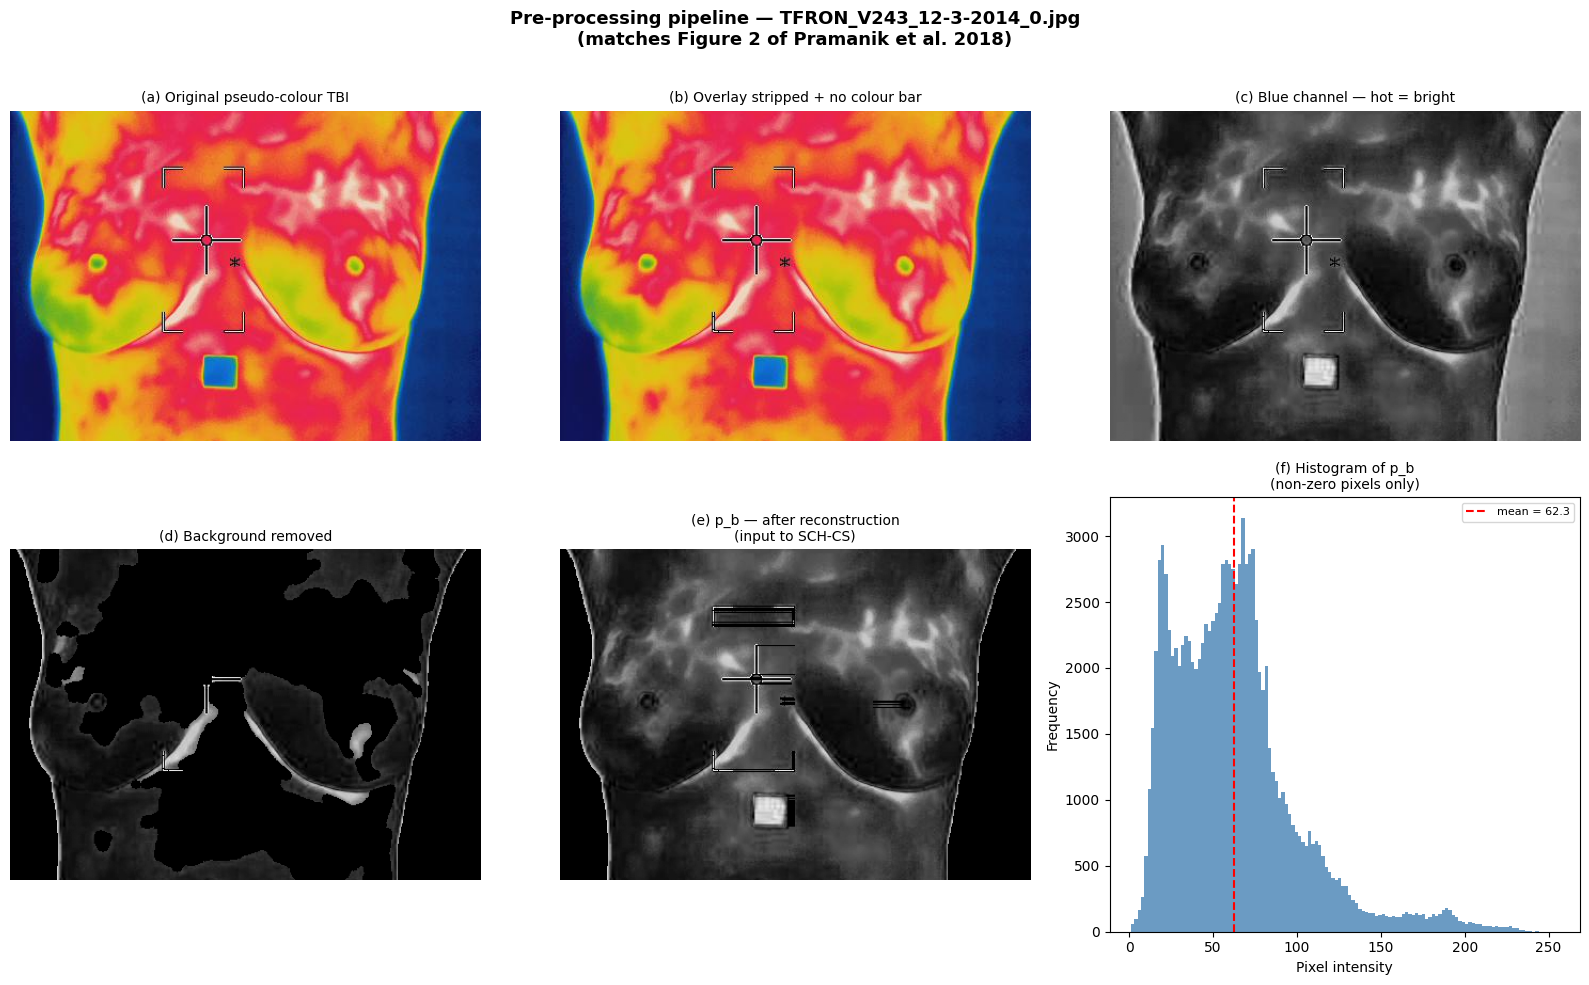

[Save] p_b saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260411_211004\TFRON_V243_12-3-2014_0_pb.png
[Save] Grayscale saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260411_211004\TFRON_V243_12-3-2014_0_grayscale.png
[Save] Background removed saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260411_211004\TFRON_V243_12-3-2014_0_bg_removed.png
[Save] Original color saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260411_211004\TFRON_V243_12-3-2014_0_original_color.png
[Save] Metadata saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260411_211004\TFRON_V243_12-3-2014_0_metadata.json

Results saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260411_211004
p_b saved at: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260411_211004\TFRON_V243_12-3-2014_0_pb.png


In [6]:
preprocessing_results = run_preprocessing(
    image_path=IMAGE_PATH,
    cfg=PRE_CFG,
    visualize=True,
    save_results=True,
    storage_config=StorageConfig(output_dir=preprocessed_results_path)
)

# PREPROCESSING RESULTS
print(f"\nResults saved to: {preprocessing_results['run_dir']}")
print(f"p_b saved at: {preprocessing_results['saved_paths']['pb']}")

In [7]:
# lOADING PRE-PROCESSING RESULTS FOR NEXT STEPS:
preprocessing_results_loaded = load_preprocessing_results(preprocessing_results['run_dir'])
pb = preprocessing_results_loaded['pb']
image_name = preprocessing_results_loaded['base_name']
print(image_name)

[Load] Loaded preprocessing results for: TFRON_V243_12-3-2014_0
pb shape: (310, 441)
TFRON_V243_12-3-2014_0


## STAGE 1: SCH-CS


  SCH-CS: TFRON_V243_12-3-2014_0

[SCH 2.1] Building histogram...
  N=109330, R=242, m=N/R=451.78, peaks found=63

[SCH 2.2] Computing rho...
  r=22, V=1258.0, C=86.9, max_h=1732 at level 73
  rho=-431.85 (fallback to m) → rho_eff=451.78

[SCH 2.3] Computing t*...
  |A|=41, A range=[98,243], m(A)=171.10, alpha(A)=42.05, t*=129.05

[SCH 2.4] Computing th...
  m(p)=62.32, t*=129.05 → th = t* = 129.05

[SCH 2.5] Thresholding (th=129.05) and labelling...
  SR pixels=5846, regions total=94, after size filter=24

[CS 2.7] Weighted centroids for 24 regions...
  R(   1): centroid=(153.3,29.4), size=575px
  R(  14): centroid=(79.5,330.0), size=986px
  R(  15): centroid=(54.1,151.1), size=21px
  R(  17): centroid=(78.3,284.3), size=553px
  R(  19): centroid=(72.4,117.7), size=191px
  R(  22): centroid=(73.9,364.8), size=73px
  R(  34): centroid=(82.0,86.5), size=29px
  R(  40): centroid=(102.5,182.1), size=30px
  R(  44): centroid=(104.0,185.0), size=27px
  R(  46): centroid=(104.8,157.6), size

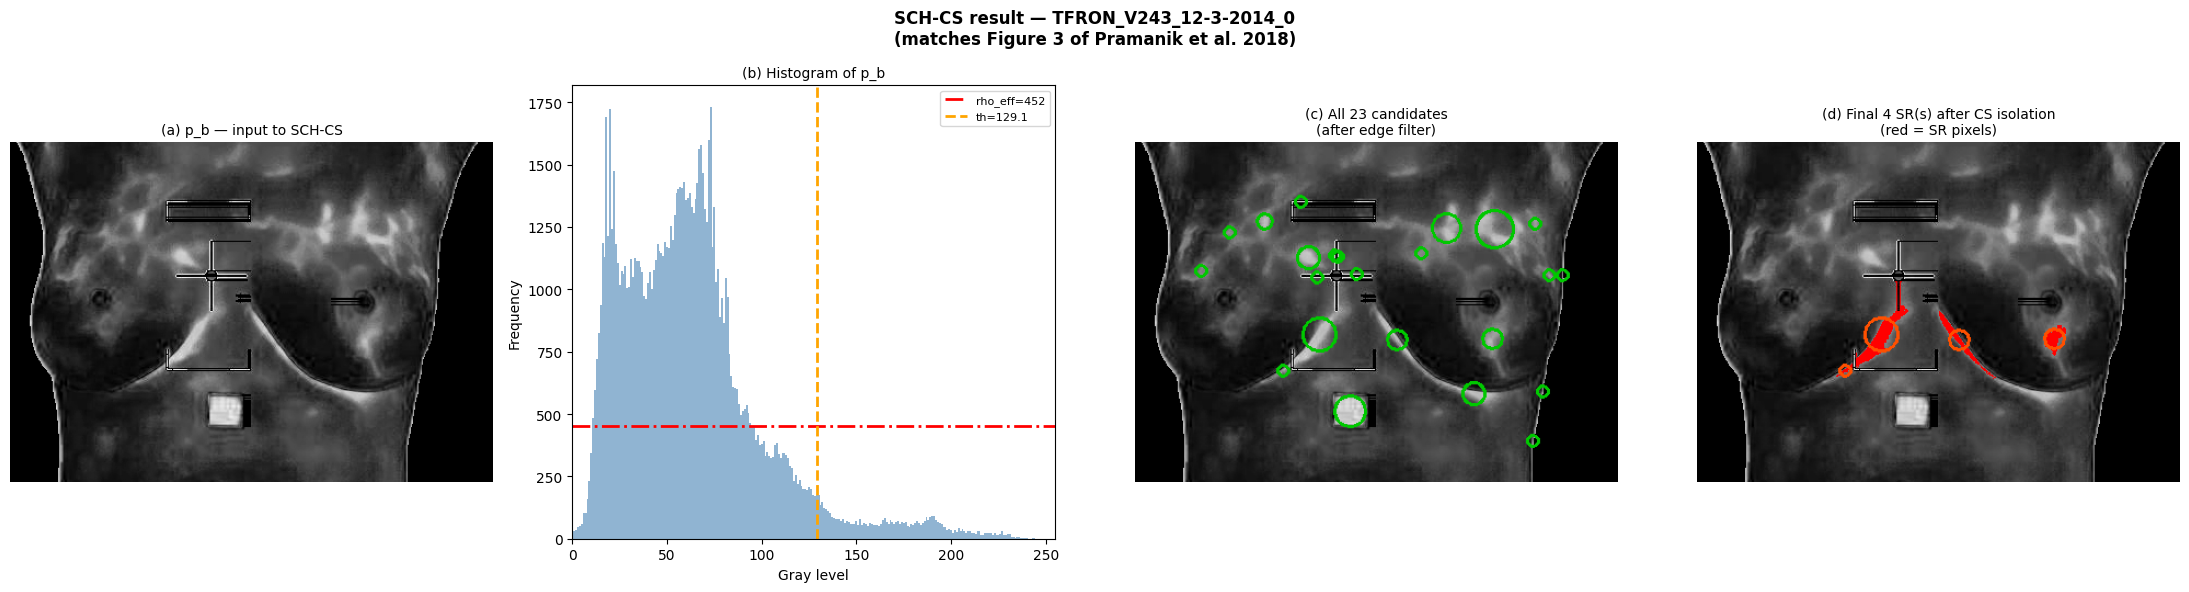


 Final SR summary:
  Label    Size(px)   Centroid(row,col)
  -------- ---------- --------------------
  65       718        (174.7, 168.4)
  67       284        (180.0, 239.0)
  69       259        (178.9, 326.3)
  79       45         (207.6, 135.3)

[Done] 4 SR(s) ready for DLPE Level Set.
[Save] Binary image saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260411_211027\TFRON_V243_12-3-2014_0_binary.png
[Save] SR mask saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260411_211027\TFRON_V243_12-3-2014_0_sr_mask.png
[Save] Labeled image saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260411_211027\TFRON_V243_12-3-2014_0_labeled.png
[Save] Regions data saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260411_211027\TFRON_V243_12-3-2014_0_regions.pkl
[Save] Metadata saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260411_211027\TFRON_V243_12-3-2014_0_metadata.json

Results saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260411_211027
Binary image (for Level Set) saved at: ..\data

In [8]:
schcs_result = run_schcs(
    pb=pb,
    cfg=SCH_CFG,
    visualize=True,
    image_name=image_name,
    save_results=True,
    storage_config=SchCsStorageConfig(output_dir=schcs_results_path)
)

# SCH-CS RESULTS
print(f"\nResults saved to: {schcs_result['run_dir']}")
print(f"Binary image (for Level Set) saved at: {schcs_result['saved_paths']['binary_image']}")

In [9]:
# GLOBAL DICTIONARY
schcs_runs = {}

# TRACKING DICTIONARY
schcs_runs[image_name] = {
    'run_dir': schcs_result['run_dir'],
    'timestamp': schcs_result['timestamp'],
    'num_regions': len(schcs_result['sr_regions'])
}

# SCH-CS RESULTS FOR LEVEL SET
schcs_results_loaded  = load_schcs_results(schcs_runs[image_name]['run_dir'])
p_th_b = schcs_results_loaded['binary_image']  # This is p_th_b for Eq 17
# GET N_SR FROM METADATA
n_sr = schcs_results_loaded['metadata']['num_sr_regions']

[Load] Binary image loaded: (310, 441)
[Load] SR mask loaded: (310, 441)
[Load] Regions data loaded
[Load] Loaded SCH-CS results for: TFRON_V243_12-3-2014_0
       Number of SR regions: 4


## STAGE 2: CHM Bias Correction


CHM Bias Field Correction - Stage 2

[Init] Output directory ready: ..\data\chm_corrected
[CHM] Input pb: shape=(310, 441), dtype=uint8, range=[0,244]
[Eq 9]  Nc = 85.0417
[Eq 10] p_bar range: [0.000, 214.599]
[CHM] p_bar : shape=(310, 441), dtype=float64
[CHM] ✓ p_bar ready.
[Save] Corrected image saved → ..\data\chm_corrected\TFRON_V243_12-3-2014_0_20260411_211040.png
[CHM] Corrected image saved to: ..\data\chm_corrected\TFRON_V243_12-3-2014_0_20260411_211040.png


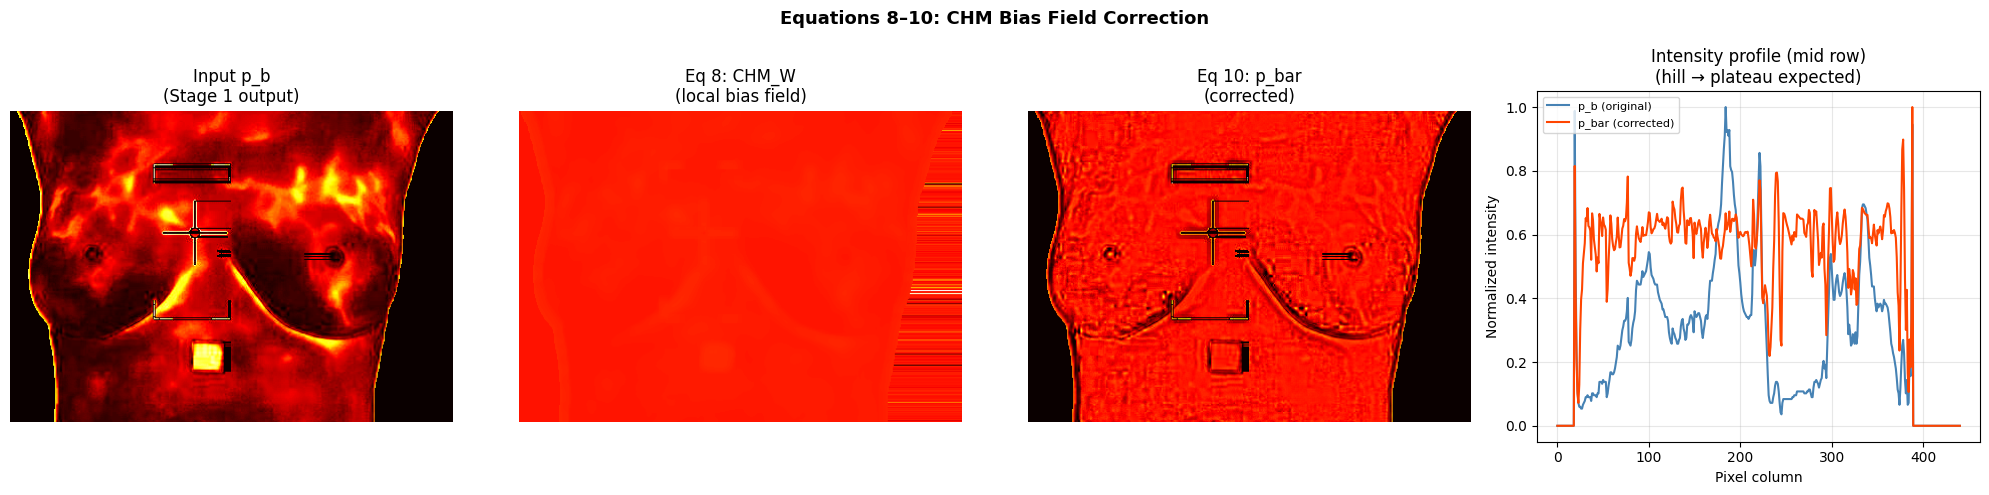


--- Verification ---
p_bar shape: (310, 441)
p_bar dtype: float64
p_bar range: [0.000, 214.599]
p_bar mean: 64.113
p_bar std: 34.750

[Ready] p_bar computed successfully.
[Ready] Corrected image saved to: ..\data\chm_corrected/
Next step → Initialize φ using SCH-CS blobs (Eq 17),
then start the DLPE Level Set iteration loop.


In [10]:
print("\n" + "="*60)
print("CHM Bias Field Correction - Stage 2")
print("="*60 + "\n")

# CHM CONFIGURATION
config = CHMConfig(
    order=1,
    window_size=9,
    show_visualization= True,
    save_visualization= False,
    save_corrected_image=True,
    output_dir=chm_corrected_results_path,
    visualization_path="chm_correction_result.png",
)

# INITIALIZE CORRECTOR
corrector = CHMCorrector(config)

try:
    if 'pb' in dir() or 'pb' in globals():
        p_bar = corrector.process(pb, image_name=image_name, visualize=True, save_image=True)
        
        print("\n--- Verification ---")
        print(f"p_bar shape: {p_bar.shape}")
        print(f"p_bar dtype: {p_bar.dtype}")
        print(f"p_bar range: [{p_bar.min():.3f}, {p_bar.max():.3f}]")
        print(f"p_bar mean: {p_bar.mean():.3f}")
        print(f"p_bar std: {p_bar.std():.3f}")
        
        print("\n[Ready] p_bar computed successfully.")
        print(f"[Ready] Corrected image saved to: {config.output_dir}/")
        print("Next step → Initialize φ using SCH-CS blobs (Eq 17),")
        print("then start the DLPE Level Set iteration loop.")
    else:
        print("Error: 'pb' variable not found. Please load your preprocessed image first.")
        
except Exception as e:
    print(f"Error: {e}")

## STAGE 2: LEVEL SET INITIALIZATION


Level Set Function φ Initialization - Stage 2 Step 2

[Init] Output directory ready: ..\data\phi_initialized
[Load]  Preprocessed TBI shape  : (310, 441)
[Load]  SCH-CS binary blob shape: (310, 441)

[Process] Initializing φ for: TFRON_V243_12-3-2014_0_pb
          Input shape: (310, 441)
[Init]  Binary image normalized from [0,255] → [0.0, 1.0]
[Eq 17] φ initialized successfully.
        Shape      : (310, 441)
        Inside SR  : 5846 pixels (4.3%) → φ = +4.0
        Outside SR : 130864 pixels (95.7%) → φ = -4.0
        φ unique values: [-4.  4.]
[Save] φ array saved → ..\data\phi_initialized\TFRON_V243_12-3-2014_0_pb_phi_20260411_211054.npy
[Save] Visualization saved → ..\data\phi_initialized\TFRON_V243_12-3-2014_0_pb_phi_viz_20260411_211054.png


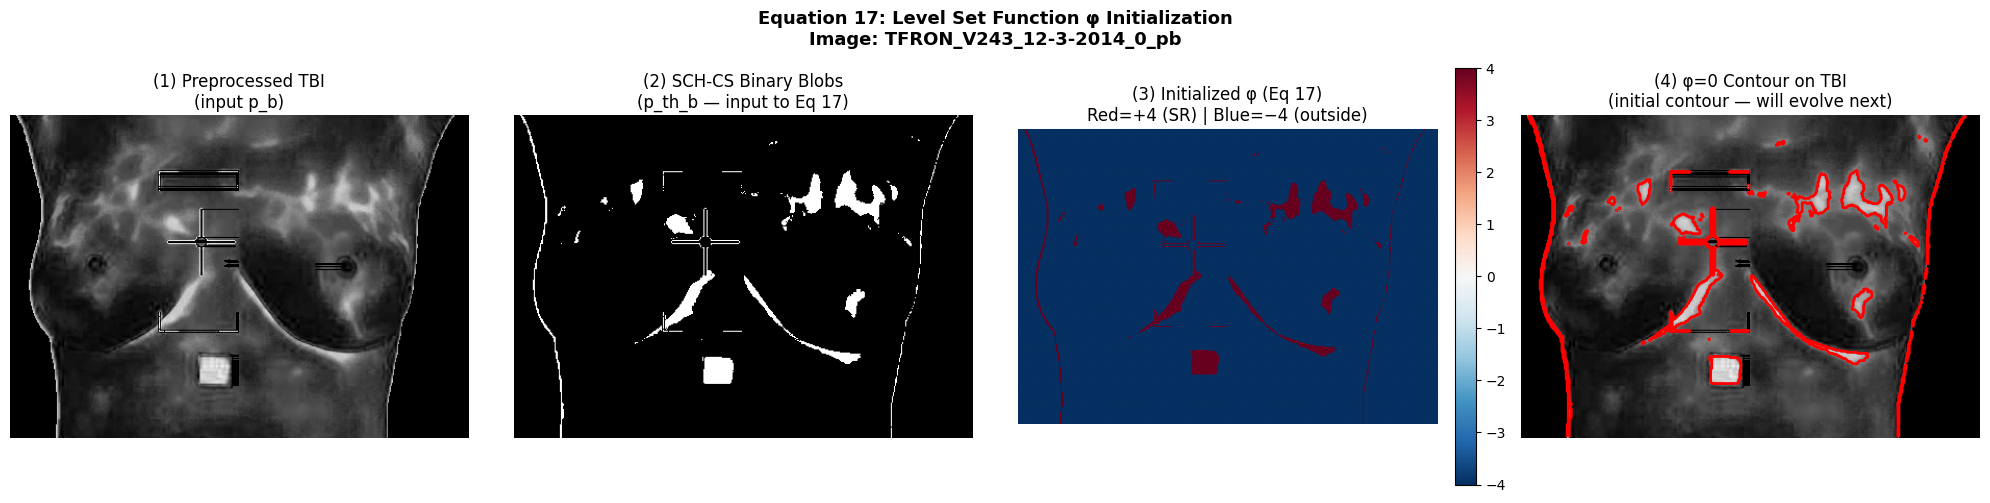


--- Verification ---
phi shape: (310, 441)
phi dtype: float64
phi values: [-4.  4.]   ← should be [-4. +4.]

[Ready] φ initialized successfully.
φ array saved to: ..\data\phi_initialized\TFRON_V243_12-3-2014_0_pb_phi_20260411_211054.npy

What you have now:
✅ p_bar — from chm_correction.py  (Eq 10)
✅ phi_init — just computed (Eq 17)
→ Next: DLPE iteration loop (Eq 18, 19, 20, 21)


In [11]:
print("\n" + "="*60)
print("Level Set Function φ Initialization - Stage 2 Step 2")
print("="*60 + "\n")

# Example paths (update with your actual paths)
PREPROCESSED_PATH = preprocessing_results['saved_paths']['pb']
SCHCS_BINARY_PATH = schcs_result['saved_paths']['binary_image']
OUTPUT_DIR = phi_initialized_result_path

# Create configuration
config = PhiInitConfig(
    inside_value=4.0,
    outside_value=-4.0,
    save_visualization=True,
    show_visualization=True,
    output_dir=OUTPUT_DIR,
    save_phi_array=True
)

# Initialize processor
initializer = LevelSetInitializer(config)

# Process from files
try:
    phi_init = initializer.process_from_files(
        preprocessed_image_path=PREPROCESSED_PATH,
        schcs_binary_path=SCHCS_BINARY_PATH,
        visualize=True
    )
    
    # Print results
    print("\n--- Verification ---")
    print(f"phi shape: {phi_init.shape}")
    print(f"phi dtype: {phi_init.dtype}")
    print(f"phi values: {np.unique(phi_init)}   ← should be [-4. +4.]")
    
    results = initializer.get_results()
    print(f"\n[Ready] φ initialized successfully.")
    print(f"φ array saved to: {results['saved_filepath']}")
    print("\nWhat you have now:")
    print("✅ p_bar — from chm_correction.py  (Eq 10)")
    print("✅ phi_init — just computed (Eq 17)")
    print("→ Next: DLPE iteration loop (Eq 18, 19, 20, 21)")
    
except Exception as e:
    print(f"Error: {e}")

## STAGE 2: LEVEL SET ITERATION


DLPE Level Set Iteration - Stage 2 Step 3

Iter    0 | l1=71.023 l2=62.920 | |1-r_prev|=1.0000 |1-r_curr|=1.0000
Iter    6 | l1=82.784 l2=15.960 | |1-r_prev|=0.0283 |1-r_curr|=0.0105


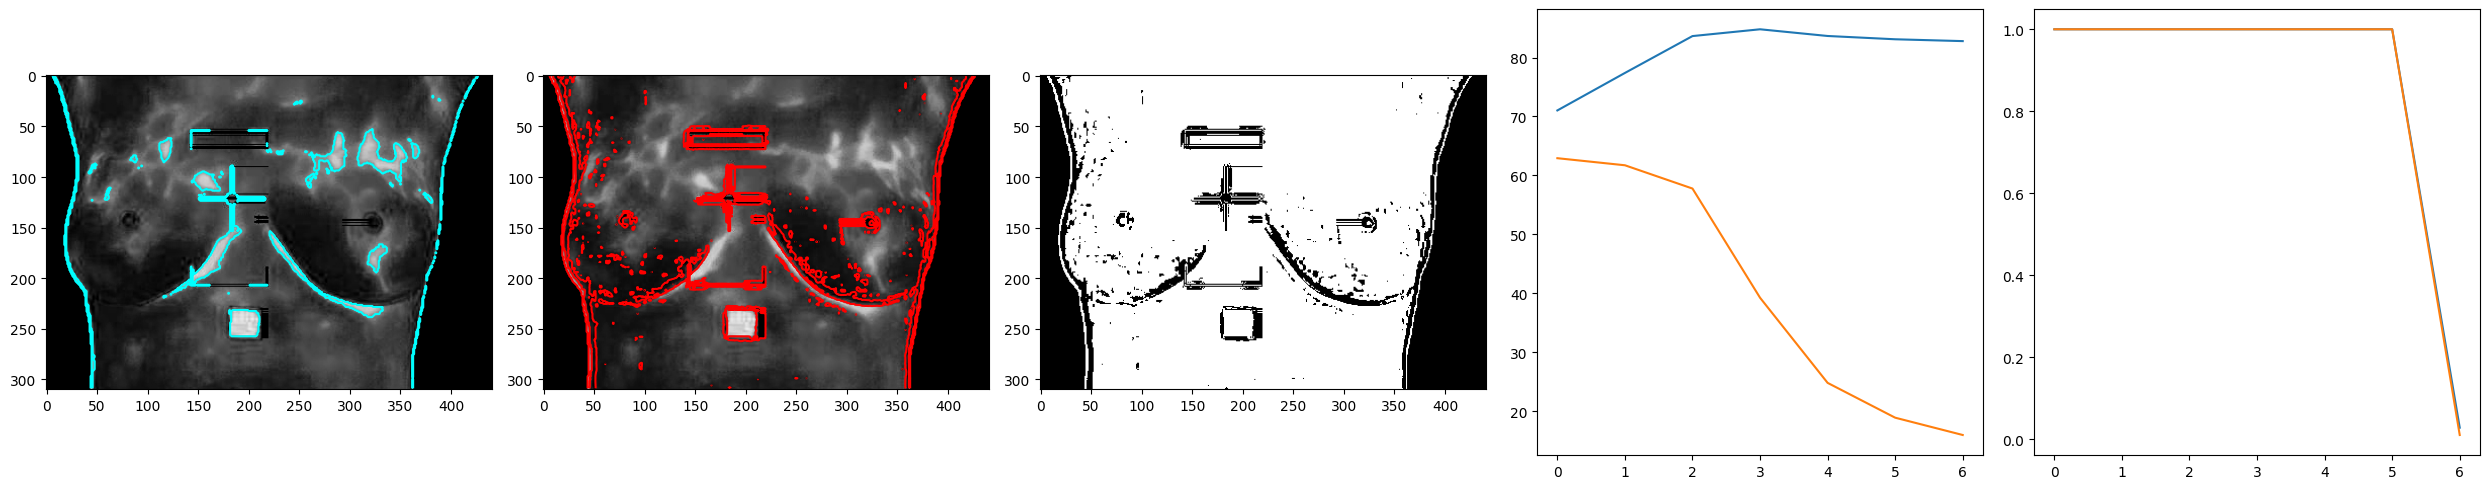


Results saved to: ..\data\level_set_iterated\TFRON_V243_12-3-2014_0_20260411_211114


In [12]:
print("\n" + "=" * 60)
print("DLPE Level Set Iteration - Stage 2 Step 3")
print("=" * 60 + "\n")

config = LevelSetConfig(output_dir=level_set_iterated_results_path)
os.makedirs(config.output_dir, exist_ok=True)

level_set_iteration_results = run_level_set(
    p_bar=p_bar,
    phi_init=phi_init,
    n_sr=n_sr,
    image_name=image_name,
    preprocessed_img=pb,
    config=config,
    verbose=True,
    do_visualize=True,
    do_save=True
)

print(f"\nResults saved to: {level_set_iteration_results['run_dir']}")

if 'segmented_sr' in level_set_iteration_results['saved_paths']:
    print(f"Segmented SR saved to: {level_set_iteration_results['saved_paths']['segmented_sr']}")

## STAGE 3: SR SEGMENTATION

[Split] Vertical centre found at column 219 (image width=441)
[Split] SR pixels — image left  half: 52847
[Split] SR pixels — image right half: 48484

sr_left  shape: (310, 441),  SR pixels: 52847
sr_right shape: (310, 441), SR pixels: 48484
[Save]  Visualization saved → sr_split_result.png


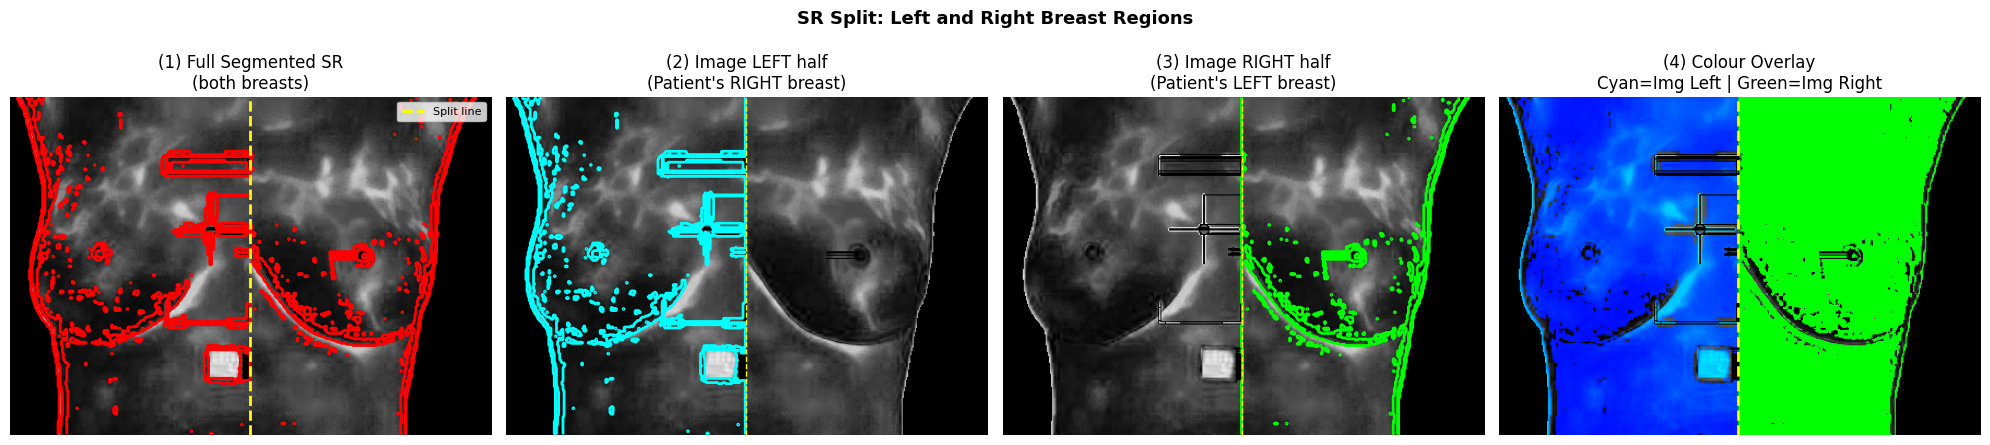

In [13]:
SEGMENTED_SR_PATH = level_set_iteration_results['saved_paths']['segmented_sr_npy']

segmented_sr = np.load(SEGMENTED_SR_PATH).astype(np.uint8)

# Call the core function directly, passing pb (numpy array) instead of a path
sr_left, sr_right, centre_col = split_sr_left_right(
    segmented_sr     = segmented_sr,
    preprocessed_img = pb # numpy array directly ✅
)

# Save outputs for feature_extraction.py
# THIS IS WHERE I NEED TO SAVE THE RESUTS IN DATETIME STAMPED FOLDER: 'sr_splits_results_path'
cv2.imwrite("sr_left.png",  sr_left  * 255)
cv2.imwrite("sr_right.png", sr_right * 255)
np.save("sr_left.npy",  sr_left)
np.save("sr_right.npy", sr_right)

print(f"\nsr_left  shape: {sr_left.shape},  SR pixels: {sr_left.sum()}")
print(f"sr_right shape: {sr_right.shape}, SR pixels: {sr_right.sum()}")

visualize_split(
    preprocessed_img = pb,
    segmented_sr     = segmented_sr,
    sr_img_left      = sr_left,
    sr_img_right     = sr_right,
    centre_col       = centre_col,
    save_path        = "sr_split_result.png"
)

## STAGE 3: FEATURE EXTRACTION

LEFT BREAST
[Feat]  Computing GLCM and 14 Haralick features...
        Haralick features: [ 3.6250000e-01  2.9428790e+02  9.0490000e-01  1.5465037e+03
  7.4050000e-01  4.8478800e+01  7.9719260e+03  2.8696000e+00
  3.6679000e+00  1.9000000e-03  1.4621000e+00 -5.5660000e-01
  9.7000000e-01  9.7170000e-01]
[Feat]  Computing 7 Hu's moment invariants...
        Hu's moments:      [-2.5177 -5.7183 -8.8522 -9.3481 10.     -9.9988 10.    ]
[Feat]  Feature vector shape: (21,)  ← ready for asymmetry step

RIGHT BREAST
[Feat]  Computing GLCM and 14 Haralick features...
        Haralick features: [ 4.0470000e-01  1.3186000e+02  9.5450000e-01  1.4477660e+03
  7.5470000e-01  4.7274100e+01  7.6495495e+03  2.6608000e+00
  3.4251000e+00  2.4000000e-03  1.3900000e+00 -5.5140000e-01
  9.6240000e-01  9.7110000e-01]
[Feat]  Computing 7 Hu's moment invariants...
        Hu's moments:      [ -2.509   -5.5407  -8.3658  -8.876  -10.      -9.991   10.    ]
[Feat]  Feature vector shape: (21,)  ← ready for asymme

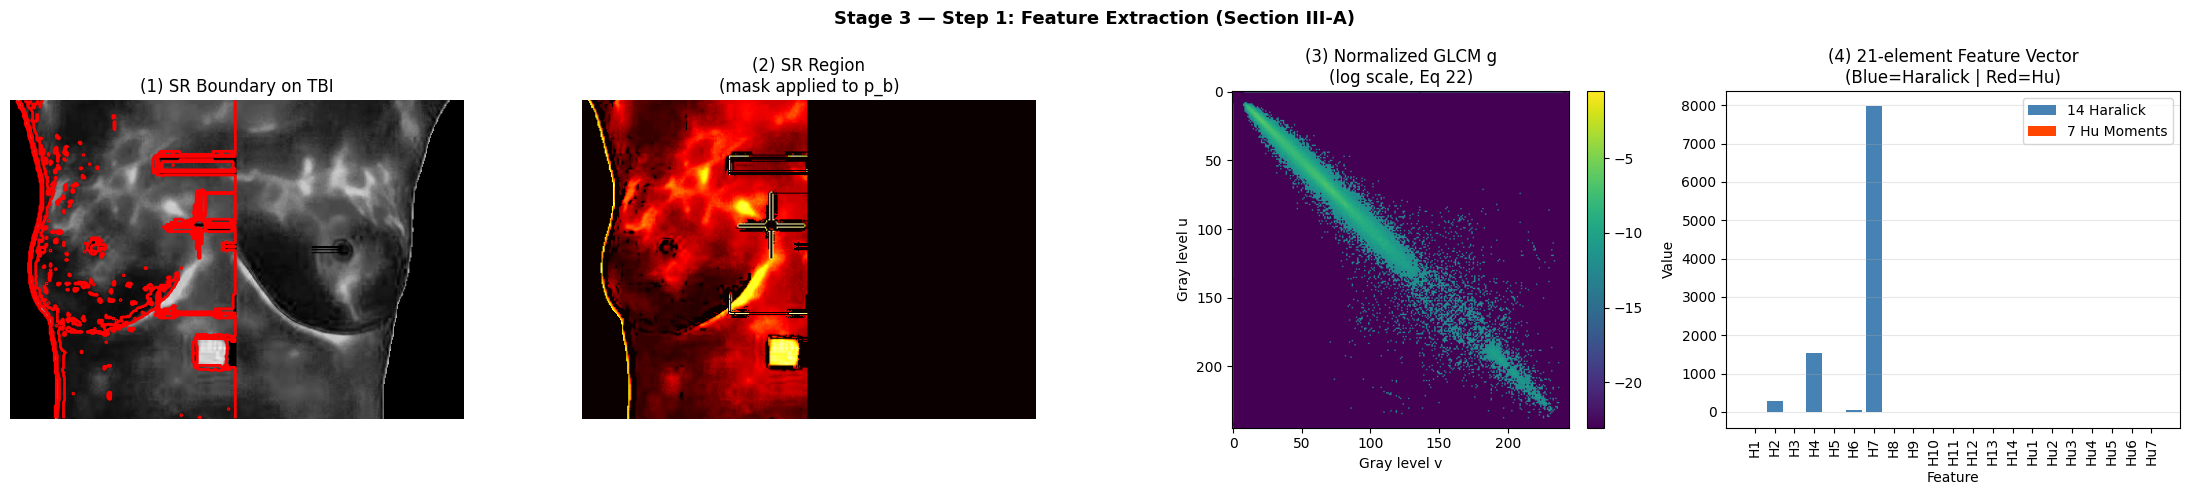


[Ready] Both feature vectors extracted.
        → Next: Asymmetry vector F = |f_v_left - f_v_right|

[Save]  f_v_left.npy and f_v_right.npy saved.
        Shape of each: (21,) ← should be (21,)


In [14]:
PREPROCESSED = preprocessing_results_loaded.get('saved_paths')['pb'] # p_b from preprocessing_tbi.py
SR_LEFT = "sr_left.png" # segmented SR — left  breast
SR_RIGHT = "sr_right.png" # segmented SR — right breast

f_v_left, f_v_right = run_feature_extraction(
    preprocessed_path = PREPROCESSED,
    sr_left_path      = SR_LEFT,
    sr_right_path     = SR_RIGHT,
    save_output       = True
)

# Save for next step (asymmetry + classification)
np.save("f_v_left.npy",  f_v_left)
np.save("f_v_right.npy", f_v_right)
print("\n[Save]  f_v_left.npy and f_v_right.npy saved.")
print("        Shape of each:", f_v_left.shape, "← should be (21,)")

## STAGE 3: ASYMMETRIC FEATURE VECTOR

SINGLE PATIENT MODE
f_v_left  : [ 3.6250000e-01  2.9428790e+02  9.0490000e-01  1.5465037e+03
  7.4050000e-01  4.8478800e+01  7.9719260e+03  2.8696000e+00
  3.6679000e+00  1.9000000e-03  1.4621000e+00 -5.5660000e-01
  9.7000000e-01  9.7170000e-01 -2.5177000e+00 -5.7183000e+00
 -8.8522000e+00 -9.3481000e+00  1.0000000e+01 -9.9988000e+00
  1.0000000e+01]
f_v_right : [ 4.0470000e-01  1.3186000e+02  9.5450000e-01  1.4477660e+03
  7.5470000e-01  4.7274100e+01  7.6495495e+03  2.6608000e+00
  3.4251000e+00  2.4000000e-03  1.3900000e+00 -5.5140000e-01
  9.6240000e-01  9.7110000e-01 -2.5090000e+00 -5.5407000e+00
 -8.3658000e+00 -8.8760000e+00 -1.0000000e+01 -9.9910000e+00
  1.0000000e+01]
F (asym.) : [4.220000e-02 1.624279e+02 4.960000e-02 9.873770e+01 1.410000e-02
 1.204700e+00 3.223765e+02 2.088000e-01 2.428000e-01 5.000000e-04
 7.210000e-02 5.200000e-03 7.600000e-03 5.000000e-04 8.700000e-03
 1.776000e-01 4.864000e-01 4.721000e-01 2.000000e+01 7.800000e-03
 0.000000e+00]
F shape   : (21,)  ← 

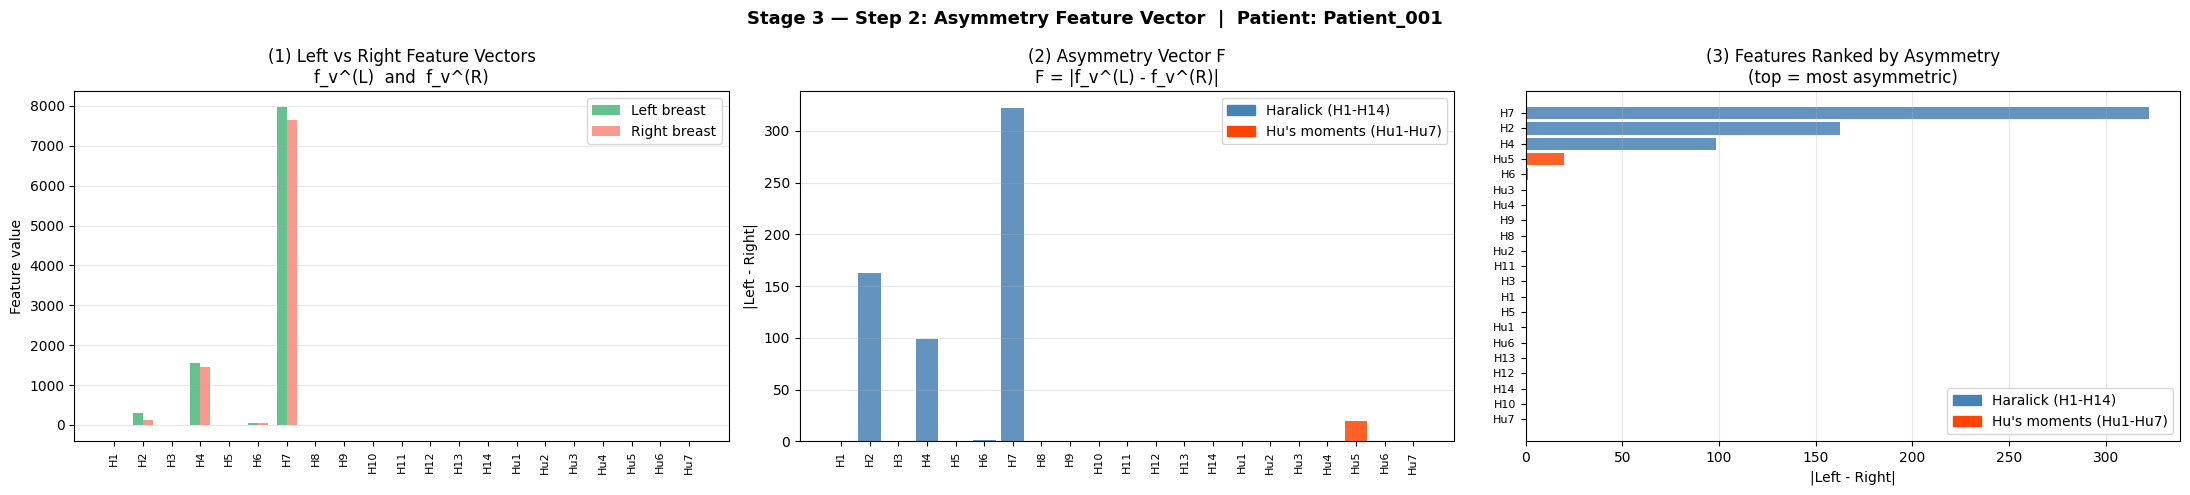


[Save]  F_single.npy saved → input to neural network (Step 3)


In [15]:
# ─────────────────────────────────────────────────────────────────────────
# SINGLE PATIENT — use this during development/testing
# ─────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("SINGLE PATIENT MODE")
print("=" * 60)

# Load feature vectors saved by feature_extraction.py
f_v_left  = np.load("f_v_left.npy")    # shape: (21,)
f_v_right = np.load("f_v_right.npy")   # shape: (21,)

# Compute asymmetry vector
F = compute_asymmetry_vector(f_v_left, f_v_right)

print(f"f_v_left  : {f_v_left.round(4)}")
print(f"f_v_right : {f_v_right.round(4)}")
print(f"F (asym.) : {F.round(4)}")
print(f"F shape   : {F.shape}  ← should be (21,)")

# Visualize
visualize_asymmetry(
    f_v_left  = f_v_left,
    f_v_right = f_v_right,
    F         = F,
    label     = "Patient_001",
    save_path = "asymmetry_result.png"
)

# Save F for the neural network (Step 3)
np.save("F_single.npy", F)
print("\n[Save]  F_single.npy saved → input to neural network (Step 3)")

# ─────────────────────────────────────────────────────────────────────────
# FULL DATASET — use this when you have all patients processed
# Structure your data as:
#   all_left  : shape (N, 21) — one row per patient
#   all_right : shape (N, 21) — one row per patient
#   labels    : shape (N,)    — 1=Abnormal, 0=Normal
# ─────────────────────────────────────────────────────────────────────────

# Example with dummy data (replace with real data):
# N = 155  (65 DMR-IR + 90 DBT-TU-JU as in paper)
# all_left  = np.load("all_feature_vectors_left.npy")   # (N, 21)
# all_right = np.load("all_feature_vectors_right.npy")  # (N, 21)
# labels    = np.load("labels.npy")                     # (N,) 0 or 1

# F_dataset, labels = build_asymmetry_dataset(all_left, all_right, labels)

# visualize_dataset_asymmetry(F_dataset, labels,
#                             save_path="dataset_asymmetry.png")

# np.save("F_dataset.npy", F_dataset)
# np.save("labels.npy",    labels)
# print("[Save]  F_dataset.npy and labels.npy → input to FANN (Step 3)")

## STAGE 3: FANN CLASSIFIER

In [ ]:
 # Step 1: Load images
# left_img = cv2.imread("sr_left.png", cv2.IMREAD_GRAYSCALE)
# right_img = cv2.imread("sr_right.png", cv2.IMREAD_GRAYSCALE)

# Step 2: Extract asymmetry vector (21 features)
# from asymmetry_vector import compute_asymmetry_vector
# F_vector = compute_asymmetry_vector(left_img, right_img)  # shape (21,)

# Step 3: Pass F_vector to scaling step
F_scaled = scaler.transform(F.reshape(1, -1))  # shape (1,21)

# Step 4: Pass scaled features to prediction
pred_class = model.predict(F_scaled, verbose=0)[0]
pred_prob = model.predict_proba(F_scaled, verbose=0)[0, 1]

# Return all intermediate results
return {
    'features_raw': F_vector,
    'features_scaled': F_scaled,
    'prediction': pred_class,
    'probability': pred_prob
}

# Usage:
results = process_single_patient(
    "left.png", "right.png",
    scaler_final, final_model
)

# Access each step's output
print(f"Raw features: {results['features_raw']}")
print(f"Scaled features: {results['features_scaled']}")
print(f"Prediction: {results['prediction']}")

In [ ]:
# ── Load dataset ──────────────────────────────────────────────────────────
# F_dataset : shape (N, 21) — from asymmetry_vector.py
# labels    : shape (N,)    — 0=Normal, 1=Abnormal

# Option A: Load from .npy files (after processing all patients)
# F_dataset = np.load("F_dataset.npy")   # (155, 21) for paper's dataset
# labels    = np.load("labels.npy")       # (155,)

# Option B: Quick test with synthetic data to verify the pipeline works
# Replace this block with real data before dissertation submission
print("[Note]  Running with SYNTHETIC data to verify pipeline.")
print("        Replace with real F_dataset.npy and labels.npy.\n")
rng       = np.random.RandomState(42)
N_normal  = 81                              # 35+46 normal  (DMR-IR + DBT)
N_abnorm  = 74                              # 30+44 abnormal
N         = N_normal + N_abnorm

# Simulate: abnormal patients have higher asymmetry (larger F values)
F_normal  = rng.uniform(0.0, 0.3, (N_normal, 21))
F_abnorm  = rng.uniform(0.2, 0.8, (N_abnorm, 21))
F_dataset = np.vstack([F_normal, F_abnorm])
labels    = np.array([0]*N_normal + [1]*N_abnorm)

# ── Run 5-fold cross-validation ───────────────────────────────────────────
results = run_cross_validation(
    F_dataset = F_dataset,
    labels    = labels,
    n_splits  = 5
)

# ── Visualize ─────────────────────────────────────────────────────────────
visualize_results(results, save_path="classification_results.png")

# ── Save final model trained on ALL data (for deployment) ─────────────────
print("\n[Train] Training final model on full dataset...")
scaler_final = StandardScaler()
F_scaled     = scaler_final.fit_transform(F_dataset)
final_model  = build_fann()
final_model.fit(F_scaled, labels)
print("[Done]  Final model ready for inference.")
print("\n        To predict a new patient:")
print("          F_new     = compute_asymmetry_vector(f_left, f_right)")
print("          F_scaled  = scaler_final.transform(F_new.reshape(1,-1))")
print("          pred      = final_model.predict(F_scaled)")
print("          prob      = final_model.predict_proba(F_scaled)[:,1]")
print("          result    = 'Abnormal' if pred[0]==1 else 'Normal'")

## Testing

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(segmented_sr, cmap='gray')
plt.title("Raw segmented_sr binary mask")
plt.axis('off')
plt.show()

In [ ]:
# ── Step 1: Check what SCH-CS actually produced ───────────────────────────
# This is p_th_b — the binary blobs BEFORE level set evolution
# Pull it from wherever your SCH-CS script saved it

plt.figure(figsize=(6, 5))
plt.imshow(p_th_b, cmap='gray')
plt.title("SCH-CS binary blobs (p_th_b)\n— should be small isolated blobs")
plt.axis('off')
plt.show()

print(f"SCH-CS white pixels: {p_th_b.sum()}")
print(f"Total pixels       : {p_th_b.size}")
print(f"Coverage           : {100*p_th_b.sum()/p_th_b.size:.1f}%")
# If coverage > 20%, SCH-CS threshold is too low → root cause found here

In [ ]:
# ── Step 2: Check phi initialization ─────────────────────────────────────
# phi should be +4 inside small blobs, -4 everywhere else

plt.figure(figsize=(6, 5))
plt.imshow(phi_init, cmap='RdBu_r')
plt.colorbar()
plt.title("Initial φ — should be mostly BLUE (-4)\nwith small RED (+4) islands")
plt.axis('off')
plt.show()

print(f"Pixels with φ=+4 (inside SR): {(phi_init > 0).sum()}")
print(f"Pixels with φ=-4 (outside)  : {(phi_init < 0).sum()}")
print(f"Coverage of +4 region       : {100*(phi_init>0).sum()/phi_init.size:.1f}%")
# If coverage > 20%, initialization is the problem

In [ ]:
# ── Step 3: Check p_bar (CHM corrected image) ─────────────────────────────
# p_bar should look like the original but with more uniform intensity
# inside the SR regions

plt.figure(figsize=(6, 5))
plt.imshow(p_bar, cmap='hot')
plt.colorbar()
plt.title("p_bar (CHM corrected)\n— should show clear bright SR regions")
plt.axis('off')
plt.show()

print(f"p_bar range: [{p_bar.min():.2f}, {p_bar.max():.2f}]")
print(f"p_bar mean : {p_bar.mean():.2f}")